In [31]:
import json
import os
from pathlib import Path
import subprocess
import sys
from datetime import datetime
import zipfile

try:
    from IPython.display import display
except ImportError:
    display = print

# Heavy plotting/data imports are loaded lazily in metric cells.
np = None
pd = None
plt = None

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'scripts' / 'train.py').is_file():
    PROJECT_ROOT = Path.cwd().parent
assert (PROJECT_ROOT / 'scripts' / 'train.py').is_file(), f'Project root not found from {Path.cwd()}'
os.chdir(PROJECT_ROOT)

PYTHON = PROJECT_ROOT / '.venv' / 'Scripts' / 'python.exe'
if not PYTHON.is_file():
    PYTHON = Path(sys.executable)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('PYTHON       =', PYTHON)


PROJECT_ROOT = d:\RL DD
PYTHON       = d:\RL DD\.venv\Scripts\python.exe


In [32]:
RUN_NAME = 'dd2_ppo_110m_v1'

TOTAL_STEPS = 10_000_000
SEED = 123
DEVICE = 'cuda'  # cuda, cpu, auto

N_ENVS = 16
N_STEPS = 2048
BATCH_SIZE = 1024
N_EPOCHS = 6
LEARNING_RATE = 2.5e-4
LR_END_RATIO = 0.08
ENT_COEF = 0.01
GAMMA = 0.995
NET_ARCH = '512,512'
MAX_EPISODE_STEPS = 120

EVAL_GLOBAL_FREQ = 100_000
CHECKPOINT_GLOBAL_FREQ = 250_000
MILESTONE_CHECKPOINTS = '10000000'
PROTECTED_BEST_MIN_STEPS = 1_000_000

RUN_DIR = PROJECT_ROOT / 'runs' / RUN_NAME
BEST_DIR = PROJECT_ROOT / 'runs' / 'best'
EVAL_DIR = RUN_DIR / 'eval'
CHECKPOINT_DIR = RUN_DIR / 'checkpoints'
FIG_DIR = RUN_DIR / 'figures'
FINAL_MODEL = RUN_DIR / 'final_model.zip'
META_JSON = RUN_DIR / 'run_meta.json'
EVAL_JSON = RUN_DIR / 'holdout_eval.json'

for path in (RUN_DIR, BEST_DIR, EVAL_DIR, CHECKPOINT_DIR, FIG_DIR):
    path.mkdir(parents=True, exist_ok=True)

if BEST_DIR.resolve() == (PROJECT_ROOT / 'runs' / 'best').resolve() and TOTAL_STEPS < PROTECTED_BEST_MIN_STEPS:
    raise ValueError(f'TOTAL_STEPS={TOTAL_STEPS} is too short to promote into runs/best')

config = {
    'run_name': RUN_NAME,
    'total_steps': TOTAL_STEPS,
    'seed': SEED,
    'device': DEVICE,
    'n_envs': N_ENVS,
    'n_steps': N_STEPS,
    'batch_size': BATCH_SIZE,
    'n_epochs': N_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'lr_end_ratio': LR_END_RATIO,
    'ent_coef': ENT_COEF,
    'gamma': GAMMA,
    'net_arch': NET_ARCH,
    'max_episode_steps': MAX_EPISODE_STEPS,
    'eval_global_freq': EVAL_GLOBAL_FREQ,
    'checkpoint_global_freq': CHECKPOINT_GLOBAL_FREQ,
    'milestone_checkpoints': MILESTONE_CHECKPOINTS,
    'best_model_save_path': str(BEST_DIR),
    'final_model': str(FINAL_MODEL),
    'eval_json': str(EVAL_JSON),
    'created_at': datetime.now().isoformat(timespec='seconds'),
}
(RUN_DIR / 'notebook_config.json').write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding='utf-8')
config


{'run_name': 'dd2_ppo_110m_v1',
 'total_steps': 10000000,
 'seed': 123,
 'device': 'cuda',
 'n_envs': 16,
 'n_steps': 2048,
 'batch_size': 1024,
 'n_epochs': 6,
 'learning_rate': 0.00025,
 'lr_end_ratio': 0.08,
 'ent_coef': 0.01,
 'gamma': 0.995,
 'net_arch': '512,512',
 'max_episode_steps': 120,
 'eval_global_freq': 100000,
 'checkpoint_global_freq': 250000,
 'milestone_checkpoints': '10000000',
 'best_model_save_path': 'd:\\RL DD\\runs\\best',
 'final_model': 'd:\\RL DD\\runs\\dd2_ppo_110m_v1\\final_model.zip',
 'eval_json': 'd:\\RL DD\\runs\\dd2_ppo_110m_v1\\holdout_eval.json',
 'created_at': '2026-05-09T10:31:43'}

In [33]:
train_cmd = [
    str(PYTHON), 'scripts/train.py',
    '--steps', str(TOTAL_STEPS),
    '--seed', str(SEED),
    '--n-envs', str(N_ENVS),
    '--device', DEVICE,
    '--learning-rate', str(LEARNING_RATE),
    '--lr-end-ratio', str(LR_END_RATIO),
    '--ent-coef', str(ENT_COEF),
    '--net-arch', NET_ARCH,
    '--n-steps', str(N_STEPS),
    '--batch-size', str(BATCH_SIZE),
    '--n-epochs', str(N_EPOCHS),
    '--gamma', str(GAMMA),
    '--max-episode-steps', str(MAX_EPISODE_STEPS),
    '--eval-global-freq', str(EVAL_GLOBAL_FREQ),
    '--checkpoint-global-freq', str(CHECKPOINT_GLOBAL_FREQ),
    '--checkpoint-save-path', str(CHECKPOINT_DIR),
    '--milestone-checkpoints', MILESTONE_CHECKPOINTS,
    '--best-model-save-path', str(BEST_DIR),
    '--eval-log-path', str(EVAL_DIR),
    '--out', str(FINAL_MODEL),
    '--run-meta-out', str(META_JSON),
]

print(' '.join(train_cmd))
process = subprocess.Popen(
    train_cmd,
    cwd=PROJECT_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
for line in process.stdout or []:
    print(line, end='')
return_code = process.wait()
print('train_return_code =', return_code)
if return_code != 0:
    raise RuntimeError(f'Training failed with code {return_code}')


d:\RL DD\.venv\Scripts\python.exe scripts/train.py --steps 10000000 --seed 123 --n-envs 16 --device cuda --learning-rate 0.00025 --lr-end-ratio 0.08 --ent-coef 0.01 --net-arch 512,512 --n-steps 2048 --batch-size 1024 --n-epochs 6 --gamma 0.995 --max-episode-steps 120 --eval-global-freq 100000 --checkpoint-global-freq 250000 --checkpoint-save-path d:\RL DD\runs\dd2_ppo_110m_v1\checkpoints --milestone-checkpoints 10000000 --best-model-save-path d:\RL DD\runs\best --eval-log-path d:\RL DD\runs\dd2_ppo_110m_v1\eval --out d:\RL DD\runs\dd2_ppo_110m_v1\final_model.zip --run-meta-out d:\RL DD\runs\dd2_ppo_110m_v1\run_meta.json
training_device=cuda
Using cuda device
Logging to runs/tb/MaskablePPO_17
d:\RL DD\.venv\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.subproc_vec_env.SubprocVecEnv object at 0x000002A4D8DD4E90> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object 

In [34]:
best_model = BEST_DIR / 'best_model.zip'
model_for_eval = best_model if best_model.is_file() else FINAL_MODEL
print('model_for_eval =', model_for_eval)

def read_sb3_zip_metadata(model_path: Path) -> dict:
    with zipfile.ZipFile(model_path) as zf:
        raw = zf.read('data').decode('utf-8')
    data = json.loads(raw)
    policy_kwargs = data.get('policy_kwargs') or {}
    return {
        'file': str(model_path),
        'size_bytes': model_path.stat().st_size,
        'num_timesteps': data.get('num_timesteps'),
        '_total_timesteps': data.get('_total_timesteps'),
        'n_steps': data.get('n_steps'),
        'batch_size': data.get('batch_size'),
        'n_epochs': data.get('n_epochs'),
        'gamma': data.get('gamma'),
        'ent_coef': data.get('ent_coef'),
        'policy_net_arch': policy_kwargs.get('net_arch'),
    }

model_meta = read_sb3_zip_metadata(model_for_eval)
display(model_meta)
if model_for_eval == best_model and (model_meta.get('_total_timesteps') or 0) < PROTECTED_BEST_MIN_STEPS:
    raise ValueError(f'Promoted best model looks like a short run: {model_meta}')

check_cmd = [
    str(PYTHON), '-c',
    "from sb3_contrib import MaskablePPO; import sys; m=MaskablePPO.load(sys.argv[1]); print('obs', m.observation_space); print('action', m.action_space)",
    str(model_for_eval),
]
subprocess.run(check_cmd, cwd=PROJECT_ROOT, check=True)


model_for_eval = d:\RL DD\runs\best\best_model.zip


{'file': 'd:\\RL DD\\runs\\best\\best_model.zip',
 'size_bytes': 10771846,
 'num_timesteps': 9800000,
 '_total_timesteps': 10000000,
 'n_steps': 2048,
 'batch_size': 1024,
 'n_epochs': 6,
 'gamma': 0.995,
 'ent_coef': 0.01,
 'policy_net_arch': [512, 512]}

CompletedProcess(args=['d:\\RL DD\\.venv\\Scripts\\python.exe', '-c', "from sb3_contrib import MaskablePPO; import sys; m=MaskablePPO.load(sys.argv[1]); print('obs', m.observation_space); print('action', m.action_space)", 'd:\\RL DD\\runs\\best\\best_model.zip'], returncode=0)

In [35]:
EVAL_EPISODES = 200
EVAL_SEEDS = '17,27,37'

eval_cmd = [
    str(PYTHON), 'scripts/evaluate.py',
    '--model', str(model_for_eval),
    '--episodes', str(EVAL_EPISODES),
    '--seeds', EVAL_SEEDS,
    '--out-json', str(EVAL_JSON),
]
print(' '.join(eval_cmd))
subprocess.run(eval_cmd, cwd=PROJECT_ROOT, check=True)

d:\RL DD\.venv\Scripts\python.exe scripts/evaluate.py --model d:\RL DD\runs\best\best_model.zip --episodes 200 --seeds 17,27,37 --out-json d:\RL DD\runs\dd2_ppo_110m_v1\holdout_eval.json


CompletedProcess(args=['d:\\RL DD\\.venv\\Scripts\\python.exe', 'scripts/evaluate.py', '--model', 'd:\\RL DD\\runs\\best\\best_model.zip', '--episodes', '200', '--seeds', '17,27,37', '--out-json', 'd:\\RL DD\\runs\\dd2_ppo_110m_v1\\holdout_eval.json'], returncode=0)

,timesteps,mean_reward,std_reward,mean_ep_length,std_ep_length,is_best
95,9600000,99.642913,30.556014,36.4750,14.154483,True
99,10000000,99.187947,26.831191,32.5625,12.054920,False
96,9700000,96.612775,32.078200,37.1375,15.391348,False
97,9800000,95.226757,29.496918,35.7500,13.944981,False
81,8200000,95.183177,35.643536,38.2625,13.112726,False
98,9900000,93.706895,33.848360,36.2875,13.734258,False
91,9200000,90.827914,39.378691,37.3875,13.856852,False
94,9500000,89.436268,32.859883,34.3625,12.867832,False
93,9400000,88.933075,38.522283,36.4375,13.804749,False
11,1200000,87.925051,35.996712,35.5125,18.031912,False


best_eval = {'timesteps': 9600000, 'mean_reward': 99.64291265, 'std_reward': 30.55601442003803, 'mean_ep_length': 36.475, 'std_ep_length': 14.15448250555279, 'is_best': True}
saved d:\RL DD\runs\dd2_ppo_110m_v1\figures\eval_callback_deep_dive.png


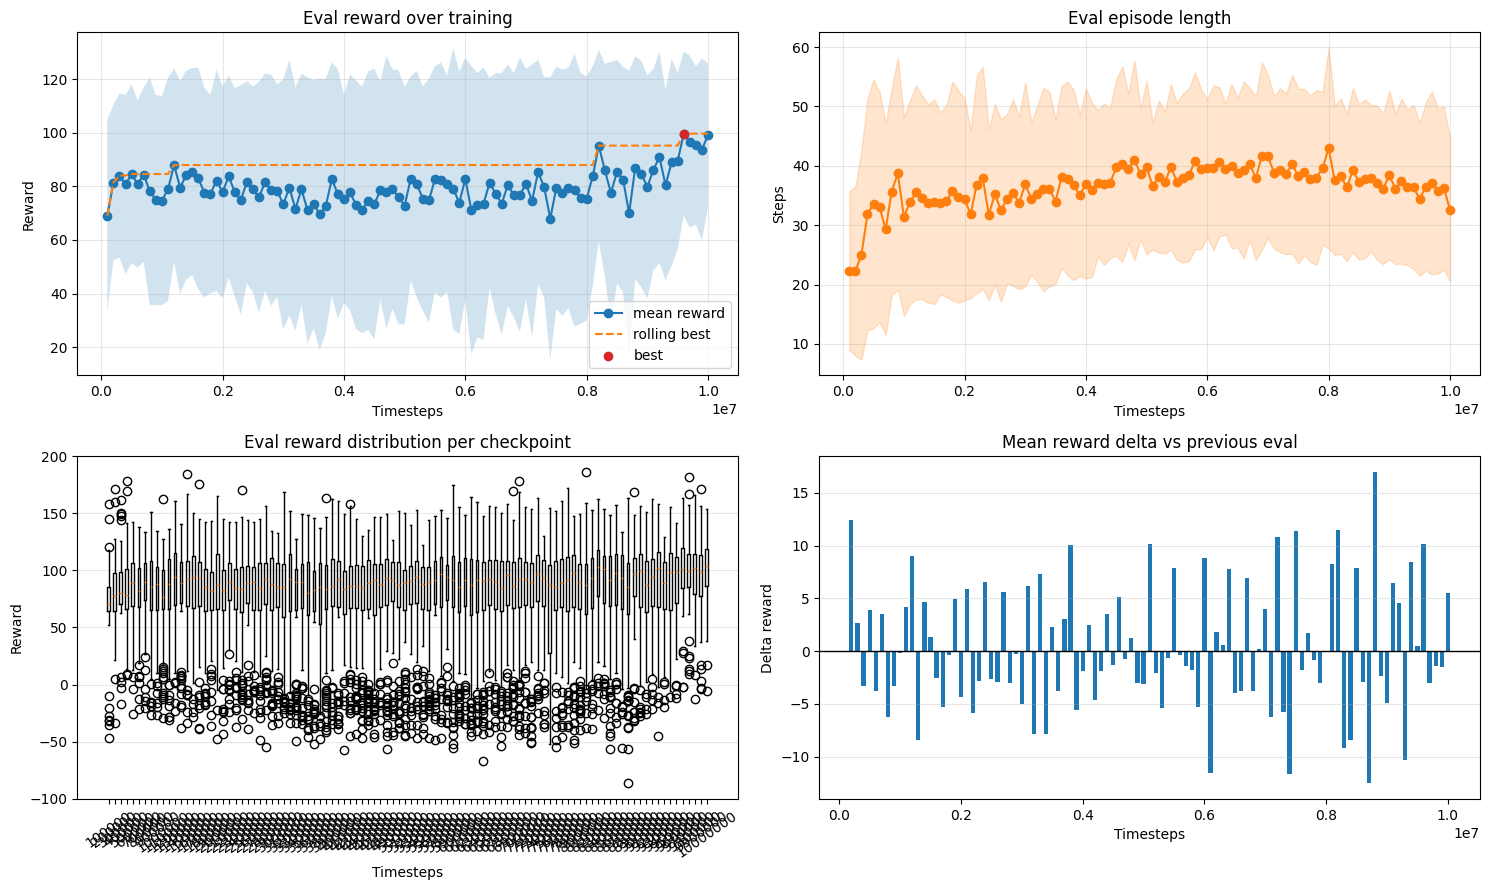

In [36]:
global np, pd, plt
if np is None:
    import numpy as np
if pd is None:
    try:
        import pandas as pd
    except ImportError:
        pd = None
if plt is None:
    import matplotlib.pyplot as plt

def plot_eval_npz(eval_npz: Path):
    data = np.load(eval_npz)
    timesteps = data['timesteps']
    results = data['results']
    ep_lengths = data['ep_lengths']
    mean_reward = results.mean(axis=1)
    std_reward = results.std(axis=1)
    mean_length = ep_lengths.mean(axis=1)
    std_length = ep_lengths.std(axis=1)
    best_idx = int(mean_reward.argmax())
    rolling_best = np.maximum.accumulate(mean_reward)

    summary_rows = []
    for idx, ts in enumerate(timesteps):
        summary_rows.append({
            'timesteps': int(ts),
            'mean_reward': float(mean_reward[idx]),
            'std_reward': float(std_reward[idx]),
            'mean_ep_length': float(mean_length[idx]),
            'std_ep_length': float(std_length[idx]),
            'is_best': idx == best_idx,
        })
    if pd is not None:
        eval_df = pd.DataFrame(summary_rows)
        display(eval_df.sort_values('mean_reward', ascending=False).head(10))
        eval_df.to_csv(FIG_DIR / 'eval_callback_summary.csv', index=False)
    else:
        display(sorted(summary_rows, key=lambda r: r['mean_reward'], reverse=True)[:10])

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    ax = axes[0, 0]
    ax.plot(timesteps, mean_reward, marker='o', label='mean reward')
    ax.plot(timesteps, rolling_best, linestyle='--', label='rolling best')
    ax.fill_between(timesteps, mean_reward - std_reward, mean_reward + std_reward, alpha=0.2)
    ax.scatter([timesteps[best_idx]], [mean_reward[best_idx]], color='tab:red', zorder=5, label='best')
    ax.set_title('Eval reward over training')
    ax.set_xlabel('Timesteps')
    ax.set_ylabel('Reward')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.plot(timesteps, mean_length, marker='o', color='tab:orange')
    ax.fill_between(timesteps, mean_length - std_length, mean_length + std_length, alpha=0.2, color='tab:orange')
    ax.set_title('Eval episode length')
    ax.set_xlabel('Timesteps')
    ax.set_ylabel('Steps')
    ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    ax.boxplot([row for row in results], positions=timesteps, widths=max(1, int((timesteps[-1] - timesteps[0]) / max(1, len(timesteps)) * 0.45)) if len(timesteps) > 1 else 1)
    ax.set_title('Eval reward distribution per checkpoint')
    ax.set_xlabel('Timesteps')
    ax.set_ylabel('Reward')
    ax.tick_params(axis='x', rotation=35)
    ax.grid(True, axis='y', alpha=0.3)

    ax = axes[1, 1]
    deltas = np.diff(mean_reward)
    ax.bar(timesteps[1:], deltas, width=max(1, int((timesteps[-1] - timesteps[0]) / max(1, len(timesteps)) * 0.7)) if len(timesteps) > 1 else 1)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title('Mean reward delta vs previous eval')
    ax.set_xlabel('Timesteps')
    ax.set_ylabel('Delta reward')
    ax.grid(True, axis='y', alpha=0.3)

    fig.tight_layout()
    out = FIG_DIR / 'eval_callback_deep_dive.png'
    fig.savefig(out, dpi=160)
    print('best_eval =', summary_rows[best_idx])
    print('saved', out)
    return fig

eval_npz = EVAL_DIR / 'evaluations.npz'
if eval_npz.is_file():
    plot_eval_npz(eval_npz)
else:
    print('No evaluations.npz found:', eval_npz)


,encounter,episodes,win_rate,mean_reward,mean_steps,survival_rate
0,holdout_double_cultist,120.0,1.000000,66.614718,21.483333,1.000000
1,holdout_double_ghoul,120.0,1.000000,107.060185,38.191667,0.993750
2,holdout_elite_pair,120.0,1.000000,109.630353,31.350000,0.981250
3,holdout_elite_swarm,120.0,0.783333,99.955488,59.066667,0.441667
4,holdout_mix_wave,120.0,1.000000,89.081816,31.766667,1.000000


terminal,loss,win
encounter,,
holdout_double_cultist,0,120
holdout_double_ghoul,0,120
holdout_elite_pair,0,120
holdout_elite_swarm,26,94
holdout_mix_wave,0,120


summary = {'win_rate': 0.9566666666666667, 'mean_reward': 94.46851187285742, 'mean_steps': 36.37166666666667, 'survival_rate': 0.8833333333333333, 'reward_stats': {'mean': 94.46851187285743, 'std': 30.039686793776426, 'min': -16.2126921182266, 'p25': 73.23269883040935, 'median': 97.44254678362572, 'p75': 113.0037192982456, 'max': 183.37584628237255}, 'steps_stats': {'mean': 36.37166666666667, 'std': 13.57216012857038, 'min': 11.0, 'p25': 26.0, 'median': 33.0, 'p75': 42.0, 'max': 73.0}, 'survival_stats': {'mean': 0.8833333333333333, 'std': 0.26047499346812975, 'min': 0.0, 'p25': 1.0, 'median': 1.0, 'p75': 1.0, 'max': 1.0}, 'composite_score': 116.08457040158869}
terminal_counts = {'loss': 26, 'win': 574}
action_counts = {'item': 906, 'pass': 7515, 'skill': 13402}
saved d:\RL DD\runs\dd2_ppo_110m_v1\figures\holdout_metrics_deep_dive.png
saved d:\RL DD\runs\dd2_ppo_110m_v1\figures\holdout_outcomes_actions.png


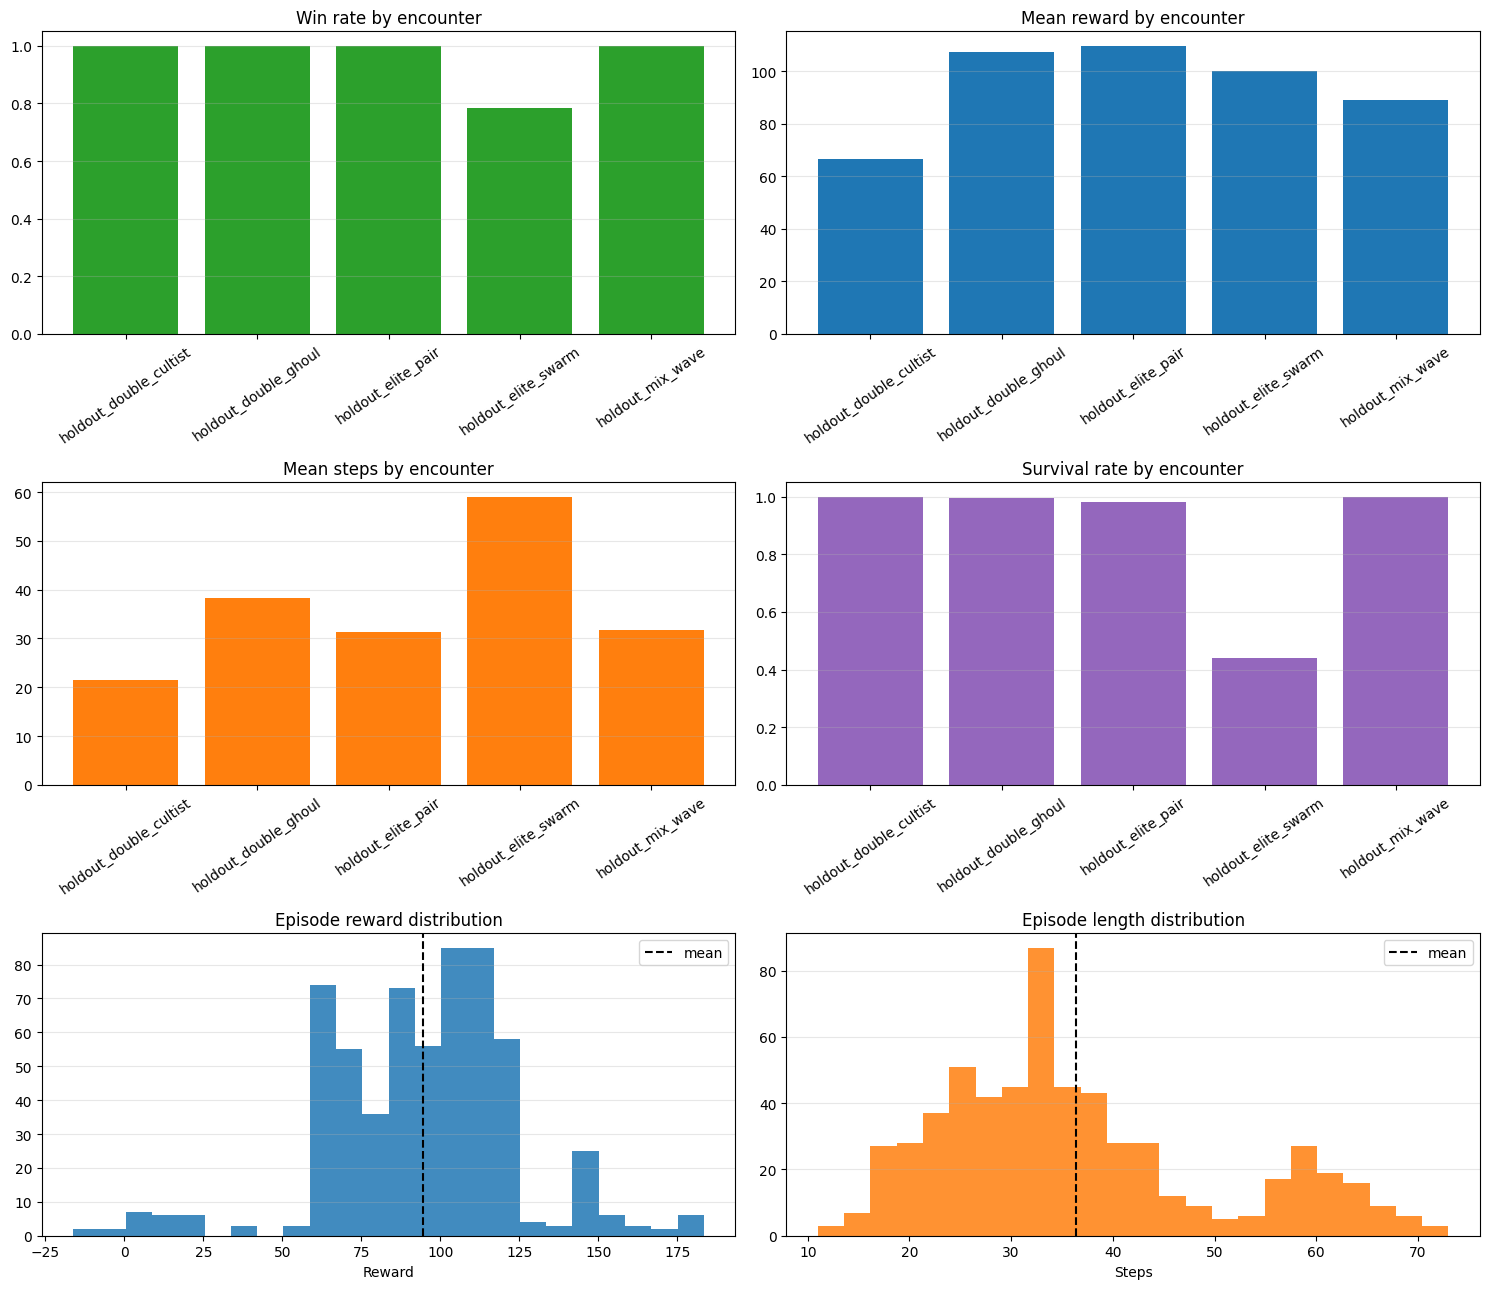

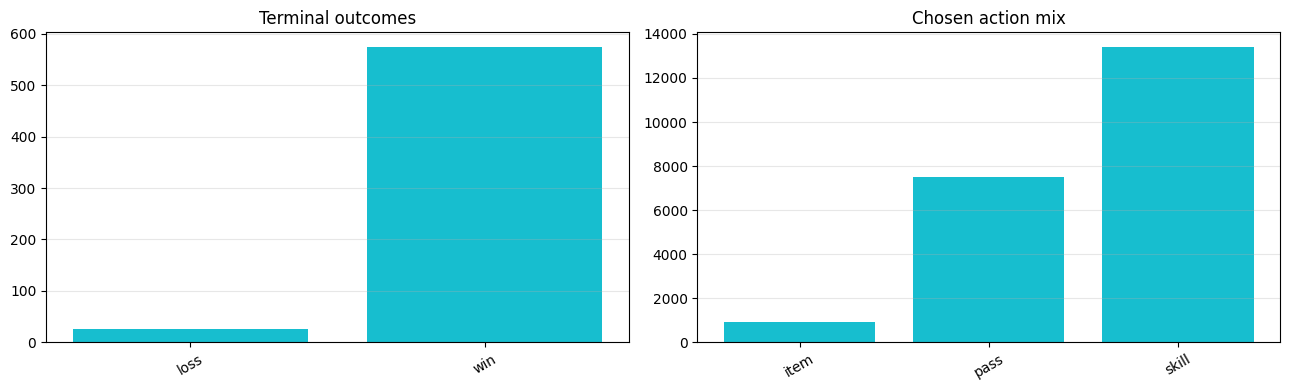

In [37]:
global pd, plt
if pd is None:
    try:
        import pandas as pd
    except ImportError:
        pd = None
if plt is None:
    import matplotlib.pyplot as plt

def _records_to_table(rows: list[dict]):
    return pd.DataFrame(rows) if pd is not None else rows

def plot_holdout_json(path: Path):
    raw = json.loads(path.read_text(encoding='utf-8'))
    encounter_rows = [{'encounter': encounter_id, **row} for encounter_id, row in raw.get('encounters', {}).items()]
    episode_rows = raw.get('episodes', [])
    if not encounter_rows:
        print('No encounter rows in', path)
        return None

    encounter_df = _records_to_table(encounter_rows)
    episode_df = _records_to_table(episode_rows)
    if pd is not None:
        encounter_df = encounter_df.sort_values('encounter')
        display(encounter_df)
        if len(episode_rows):
            display(episode_df.groupby(['encounter', 'terminal']).size().unstack(fill_value=0))
            episode_df.to_csv(FIG_DIR / 'holdout_episodes.csv', index=False)
        encounter_df.to_csv(FIG_DIR / 'holdout_encounters.csv', index=False)
    else:
        display(encounter_df)

    encounters = list(encounter_df['encounter']) if pd is not None else [r['encounter'] for r in encounter_df]
    win_rate = list(encounter_df['win_rate']) if pd is not None else [r['win_rate'] for r in encounter_df]
    mean_reward = list(encounter_df['mean_reward']) if pd is not None else [r['mean_reward'] for r in encounter_df]
    mean_steps = list(encounter_df['mean_steps']) if pd is not None else [r['mean_steps'] for r in encounter_df]
    survival_rate = list(encounter_df['survival_rate']) if pd is not None else [r['survival_rate'] for r in encounter_df]

    fig, axes = plt.subplots(3, 2, figsize=(15, 13))
    axes = axes.ravel()
    bar_series = [
        ('Win rate by encounter', win_rate, 'tab:green'),
        ('Mean reward by encounter', mean_reward, 'tab:blue'),
        ('Mean steps by encounter', mean_steps, 'tab:orange'),
        ('Survival rate by encounter', survival_rate, 'tab:purple'),
    ]
    for ax, (title, values, color) in zip(axes[:4], bar_series):
        ax.bar(encounters, values, color=color)
        ax.set_title(title)
        ax.tick_params(axis='x', rotation=35)
        ax.grid(True, axis='y', alpha=0.3)

    rewards = [r['reward'] for r in episode_rows]
    steps = [r['steps'] for r in episode_rows]
    if rewards:
        axes[4].hist(rewards, bins=24, color='tab:blue', alpha=0.85)
        axes[4].axvline(raw['summary']['mean_reward'], color='black', linestyle='--', label='mean')
        axes[4].set_title('Episode reward distribution')
        axes[4].set_xlabel('Reward')
        axes[4].legend()
        axes[4].grid(True, axis='y', alpha=0.3)
    if steps:
        axes[5].hist(steps, bins=24, color='tab:orange', alpha=0.85)
        axes[5].axvline(raw['summary']['mean_steps'], color='black', linestyle='--', label='mean')
        axes[5].set_title('Episode length distribution')
        axes[5].set_xlabel('Steps')
        axes[5].legend()
        axes[5].grid(True, axis='y', alpha=0.3)

    fig.tight_layout()
    out = FIG_DIR / 'holdout_metrics_deep_dive.png'
    fig.savefig(out, dpi=160)
    print('summary =', raw.get('summary'))
    print('terminal_counts =', raw.get('terminal_counts'))
    print('action_counts =', raw.get('action_counts'))
    print('saved', out)

    if raw.get('action_counts') or raw.get('terminal_counts'):
        fig2, axes2 = plt.subplots(1, 2, figsize=(13, 4))
        for ax, title, counts in [
            (axes2[0], 'Terminal outcomes', raw.get('terminal_counts', {})),
            (axes2[1], 'Chosen action mix', raw.get('action_counts', {})),
        ]:
            labels = list(counts.keys())
            values = list(counts.values())
            ax.bar(labels, values, color='tab:cyan')
            ax.set_title(title)
            ax.tick_params(axis='x', rotation=30)
            ax.grid(True, axis='y', alpha=0.3)
        fig2.tight_layout()
        out2 = FIG_DIR / 'holdout_outcomes_actions.png'
        fig2.savefig(out2, dpi=160)
        print('saved', out2)
    return fig

if EVAL_JSON.is_file():
    plot_holdout_json(EVAL_JSON)
else:
    print('No holdout JSON found:', EVAL_JSON)
